In [1]:
import numpy as np
import lmfit
from surface_code import SurfaceCode
from distributed_surface_code import DistributedSurfaceCode
import sinter
from typing import List
import os
import matplotlib.pyplot as plt

## Fitting for regular code

In [ ]:
hardware_params = {
        'T1': 250e-6,  # in seconds
        'T2': 250e-6,  # in seconds
        'duration_1q_gate': 20e-9,  # in seconds
        'duration_2q_gate': 30e-9,  # in seconds
        'state_prep_error': 1e-3,
        'measurement_error': 1e-3,
        'gate_error_1q': 1e-3,
        'gate_error_2q': 1e-3,
        'duration_readout': 500e-9,
    }

# IMPORTANT: ad and idle_depol ARE INCOMPATIBLE, ONLY SELECT ONE
ad = False
crosstalk = False
idle_depol = True

distances = [5, 7, 9, 11]

n_runs = 10_000_000
max_errors = 1_000_000

multipliers = np.logspace(-1, 0, 7)
print(multipliers*hardware_params['gate_error_1q'])

[0.0001     0.00014678 0.00021544 0.00031623 0.00046416 0.00068129
 0.001     ]


In [ ]:
from joblib import Parallel, delayed
import itertools
import os
import sinter

def _make_surface_task(distance, multiplier):
    circuit = SurfaceCode(
        hardware_params, distance, 3*distance, ad, crosstalk, 'CX',
        True, 'z', multiplier, idle_depol
    ).build_surface_code_circuit()

    return sinter.Task(
        circuit=circuit,
        json_metadata={
            'p': hardware_params['gate_error_1q'] * multiplier,
            'd': distance,
        },
    )

pairs = list(itertools.product(distances, multipliers))

# Leave at least 1 core free (and consider leaving more if you also parallelize sinter.collect)
n_jobs = max(1, (os.cpu_count() or 2) - 1)

surface_code_tasks = Parallel(n_jobs=n_jobs, backend="loky", batch_size=10)(
    delayed(_make_surface_task)(d, m) for d, m in pairs
)


Starting 16 workers...
28 tasks left:
  workers    decoder   eta shots_left errors_seen json_metadata                
        1 pymatching     ?   10000000           0 p=0.0001,d=5                 
        1 pymatching 2667m    9999999           0 p=0.00014677992676220695,d=5 
        1 pymatching     ?   10000000           0 p=0.00021544346900318834,d=5 
        1 pymatching     ?   10000000           0 p=0.00031622776601683794,d=5 
        1 pymatching     ?   10000000           0 p=0.0004641588833612779,d=5  
        1 pymatching     ?   10000000           0 p=0.0006812920690579612,d=5  
        1 pymatching     ?   10000000           0 p=0.001,d=5                  
        1 pymatching     ?   10000000           0 p=0.0001,d=7                 
        1 pymatching     ?   10000000           0 p=0.00014677992676220695,d=7 
        1 pymatching     ?   10000000           0 p=0.00021544346900318834,d=7 
        1 pymatching     ?   10000000           0 p=0.00031622776601683794,d=7 
  

In [ ]:

surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=n_runs,
    print_progress=True,
)

In [6]:
x = []
data = []
shots = n_runs

for stats in surface_code_stats:
    p = stats.json_metadata['p']
    d = stats.json_metadata['d']
    
    if not stats.errors:
        print(f"Didn't see any errors for d={d}")
        continue
    
    x.append([p, d])
    
    per_shot = stats.errors / stats.shots
    data.append(per_shot)

Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=11
Didn't see any errors for d=11
Didn't see any errors for d=11


In [7]:
print(x)

[[np.float64(0.00014677992676220695), 5], [np.float64(0.0004641588833612779), 5], [np.float64(0.00031622776601683794), 5], [np.float64(0.001), 5], [np.float64(0.0001), 5], [np.float64(0.0006812920690579612), 5], [np.float64(0.00021544346900318834), 5], [np.float64(0.00014677992676220695), 7], [np.float64(0.00021544346900318834), 7], [np.float64(0.0006812920690579612), 7], [np.float64(0.00031622776601683794), 7], [np.float64(0.001), 7], [np.float64(0.0001), 7], [np.float64(0.0004641588833612779), 7], [np.float64(0.00021544346900318834), 9], [np.float64(0.00031622776601683794), 9], [np.float64(0.0004641588833612779), 9], [np.float64(0.0006812920690579612), 9], [np.float64(0.001), 9], [np.float64(0.00031622776601683794), 11], [np.float64(0.0004641588833612779), 11], [np.float64(0.0006812920690579612), 11], [np.float64(0.001), 11]]


In [8]:
print(data)

[2.66e-05, 0.0008556, 0.0002768, 0.0080583, 8.3e-06, 0.0026473, 9.04e-05, 1.8e-06, 5.2e-06, 0.0006559, 3.2e-05, 0.0030073, 4e-07, 0.0001457, 3e-07, 2.7e-06, 2.21e-05, 0.0001344, 0.0010085, 1e-07, 2.3e-06, 3.25e-05, 0.0003166]


In [9]:
# x = [p, d] # d: code distance
def p_L(x, data):
    return 1 - np.power((1 - data), 1/(3 * x[1]))

def std(x, data, shots):
    k = 3 * x[1]
    return np.sqrt(data * (1 - data) / shots)/(k * np.power(1 - data, 1 - 1/k))

def ansatz(x, alpha, p_th):
    return alpha * np.power(x[0] / p_th, (x[1] + 1)/2)
   
def cost(params, x, data, shots):
    alpha = params['alpha'].value
    p_th = params['p_th'].value

    values = []
    for xi, di in zip(x, data):
        model = ansatz(xi, alpha, p_th)
        values.append((p_L(xi, di) - model) / std(xi, di, shots))
    return values


In [10]:
params = lmfit.Parameters()
params['alpha'] = lmfit.Parameter(name='alpha', value = 0.01)
params['p_th'] = lmfit.Parameter(name='p_th', value = 0.05, max=1, min=0)

surface_code_results = lmfit.minimize(cost, params, args=(x, data, shots))
print(lmfit.fit_report(surface_code_results))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 53
    # data points      = 23
    # variables        = 2
    chi-square         = 96.3880067
    reduced chi-square = 4.58990508
    Akaike info crit   = 36.9564140
    Bayesian info crit = 39.2274025
[[Variables]]
    alpha:  0.03095887 +/- 7.8254e-04 (2.53%) (init = 0.01)
    p_th:   0.00383791 +/- 2.7777e-05 (0.72%) (init = 0.05)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, p_th) = +0.9790


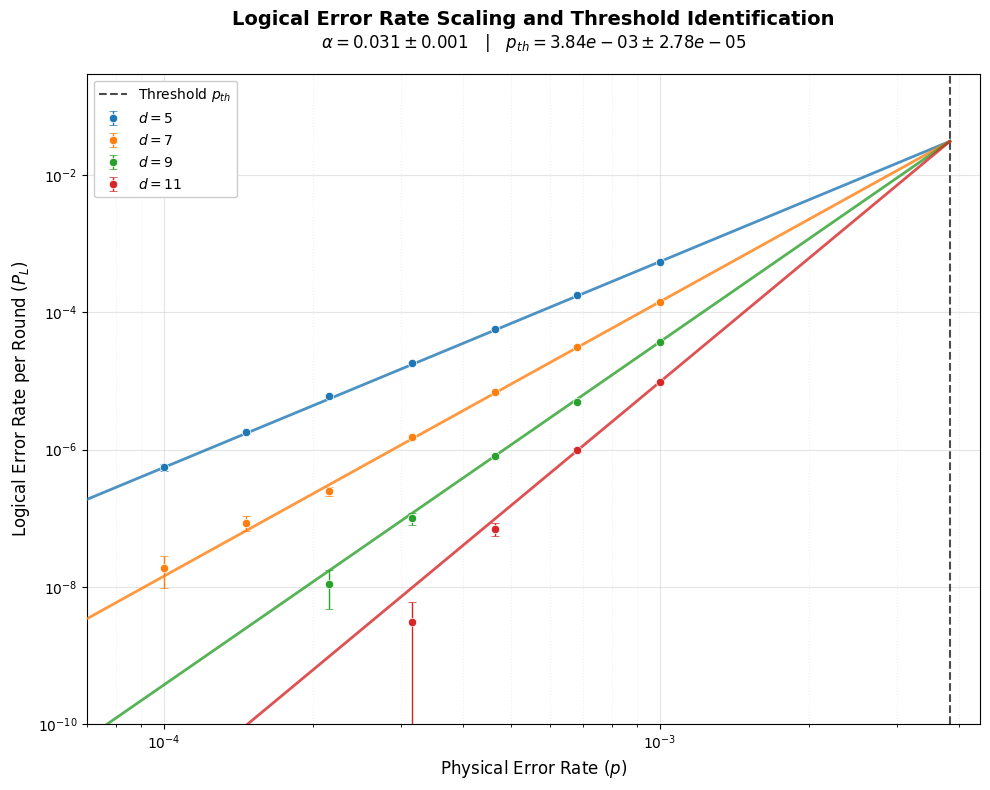

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------- pull best-fit params and errors ----------
alpha_param = surface_code_results.params["alpha"]
pth_param = surface_code_results.params["p_th"]

alpha_hat, alpha_err = alpha_param.value, alpha_param.stderr or 0
pth_hat, pth_err = pth_param.value, pth_param.stderr or 0

# ---------- compute points ----------
x_arr = np.array(x, dtype=float)
p_pts = x_arr[:, 0]
d_pts = x_arr[:, 1].astype(int)
data_arr = np.array(data)

pL_pts = np.array([p_L(xi, di) for xi, di in zip(x_arr, data_arr)], dtype=float)

# ---------- make plot ----------
plt.figure(figsize=(10, 8))

# Basic Scientific Colors: 'tab10' provides standard, high-contrast colors
unique_distances = sorted(set(d_pts))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Standard windowing
p_min_plot = p_pts.min() * 0.7 
p_max_plot = pth_hat * 1.15
p_grid = np.logspace(np.log10(p_min_plot), np.log10(pth_hat), 400)

for i, d in enumerate(unique_distances):
    mask = (d_pts == d)
    if not np.any(mask): continue
    
    # Error Bars
    y_errs = [std([p, d], dat, shots) for p, dat in zip(p_pts[mask], data_arr[mask])]
    
    # Scatter points with standard colors
    plt.errorbar(p_pts[mask], pL_pts[mask], yerr=y_errs, fmt='o', 
                 label=f"$d={d}$", color=colors[i], capsize=3, 
                 elinewidth=1.0, markersize=6, markeredgecolor='white', 
                 markeredgewidth=0.5, zorder=4)

    # Fit lines
    y_fit = ansatz([p_grid, np.full_like(p_grid, d, dtype=float)], alpha_hat, pth_hat)
    plt.plot(p_grid, y_fit, color=colors[i], linestyle='-', linewidth=2.0, alpha=0.8, zorder=3)

# --- Axis Styling ---
plt.xscale("log")
plt.yscale("log")
plt.xlim(p_min_plot, p_max_plot)
plt.ylim(1e-10, 0.3) 

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))

# Threshold Marker
plt.axvline(pth_hat, color='black', linestyle="--", linewidth=1.5, alpha=0.7, 
            label=f"Threshold $p_{{th}}$", zorder=2)

# --- Professional Title with extra spacing ---
# We use a larger pad and a manual newline '\n\n' or small font spacer
plt.title("Logical Error Rate Scaling and Threshold Identification", 
          fontsize=14, fontweight='bold', pad=35) # Increased pad for overall distance

subtitle = fr"$\alpha = {alpha_hat:.3f} \pm {alpha_err:.3f} \quad | \quad p_{{th}} = {pth_hat:.2e} \pm {pth_err:.2e}$"

# Placing the subtitle manually allows for precise control over the 'gap'
plt.text(0.5, 1.03, subtitle, transform=ax.transAxes, ha='center', fontsize=12, va='bottom')

plt.xlabel("Physical Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate per Round ($P_L$)", fontsize=12)

plt.grid(True, which="major", ls="-", color='0.8', alpha=0.5, zorder=1)
plt.grid(True, which="minor", ls=":", color='0.8', alpha=0.3, zorder=1)

plt.legend(loc='upper left', frameon=True, fontsize=10, facecolor='white', framealpha=1)

plt.tight_layout()
plt.show()

## Fitting for distributed code

In [9]:
distr_hardware_params = {
        'T1': 250e-6,  # in seconds
        'T2': 250e-6,  # in seconds
        'duration_1q_gate': 20e-9,  # in seconds
        'duration_2q_gate': 30e-9,  # in seconds
        'state_prep_error': 1e-3,
        'measurement_error': 1e-3,
        'gate_error_1q': 1e-3,
        'gate_error_2q': 1e-3,
        'duration_readout': 500e-9,
        'p_Bell': 1e-1,
        'duration_Bell_prep': 1e-6,
    }

# IMPORTANT: ad and idle_depol ARE INCOMPATIBLE, ONLY SELECT ONE
ad = False
crosstalk = False
idle_depol = True

distances = [5, 7, 9, 11, 13]

n_runs = 10_000_000
max_errors = 1_000_000

multipliers = np.logspace(-1, 0, 40)
pBell_multipliers = np.logspace(-2, np.log10(0.5), 40)
print("p = ", multipliers*distr_hardware_params["gate_error_1q"])
print("p_Bell = ", pBell_multipliers*distr_hardware_params["p_Bell"])

p =  [0.0001     0.00010608 0.00011253 0.00011938 0.00012664 0.00013434
 0.00014251 0.00015118 0.00016037 0.00017013 0.00018047 0.00019145
 0.00020309 0.00021544 0.00022855 0.00024245 0.00025719 0.00027283
 0.00028943 0.00030703 0.0003257  0.00034551 0.00036652 0.00038882
 0.00041246 0.00043755 0.00046416 0.00049239 0.00052233 0.0005541
 0.0005878  0.00062355 0.00066147 0.0007017  0.00074438 0.00078965
 0.00083768 0.00088862 0.00094267 0.001     ]
p_Bell =  [0.001      0.00110551 0.00122216 0.00135111 0.00149367 0.00165126
 0.00182549 0.0020181  0.00223104 0.00246644 0.00272667 0.00301437
 0.00333242 0.00368403 0.00407274 0.00450246 0.00497752 0.00550271
 0.00608331 0.00672517 0.00743476 0.00821921 0.00908643 0.01004516
 0.01110504 0.01227675 0.01357209 0.0150041  0.01658721 0.01833735
 0.02027216 0.02241111 0.02477574 0.02738987 0.03027982 0.0334747
 0.03700667 0.04091131 0.04522793 0.05      ]


In [ ]:
from joblib import Parallel, delayed
import itertools
import sinter

def make_task(distance, multiplier, pBell_multiplier):
    circuit = DistributedSurfaceCode(
        distr_hardware_params, distance, 3*distance, ad, crosstalk, 'CX',
        True, 'z', multiplier, pBell_multiplier, idle_depol
    ).build_surface_code_circuit()
    return sinter.Task(
        circuit=circuit,
        json_metadata={
            'p': distr_hardware_params['gate_error_1q'] * multiplier,
            'd': distance,
            'p_Bell': distr_hardware_params['p_Bell'] * pBell_multiplier
        },
    )

triples = list(itertools.product(distances, multipliers, pBell_multipliers))
distributed_surface_code_tasks = Parallel(n_jobs=25, backend="loky")(
    delayed(make_task)(d, m, pb) for d, m, pb in triples
)
print(len(distributed_surface_code_tasks))

In [ ]:

distributed_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=30,
    tasks=distributed_surface_code_tasks,
    decoders=['pymatching'],
    max_shots=n_runs,
    print_progress=False,
)

In [5]:
x = []
data = []
shots = n_runs

for stats in distributed_surface_code_stats:
    p = stats.json_metadata['p']
    d = stats.json_metadata['d']
    p_Bell = stats.json_metadata['p_Bell']
    
    if not stats.errors:
        print(f"Didn't see any errors for d={d}")
        continue
    
    x.append([p, d, p_Bell])
    
    per_shot = stats.errors / stats.shots
    
    data.append(per_shot)

Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see

In [ ]:
print(x)

[[np.float64(0.0001), 5, np.float64(0.0019193831036664845)], [np.float64(0.0001), 5, np.float64(0.007071067811865475)], [np.float64(0.0001), 5, np.float64(0.001)], [np.float64(0.00014677992676220695), 5, np.float64(0.0019193831036664845)], [np.float64(0.00014677992676220695), 5, np.float64(0.05)], [np.float64(0.0001), 5, np.float64(0.05)], [np.float64(0.00014677992676220695), 5, np.float64(0.013572088082974533)], [np.float64(0.00014677992676220695), 5, np.float64(0.001)], [np.float64(0.0001), 5, np.float64(0.026050036547934564)], [np.float64(0.00014677992676220695), 5, np.float64(0.0036840314986403867)], [np.float64(0.0001), 5, np.float64(0.013572088082974533)], [np.float64(0.00014677992676220695), 5, np.float64(0.007071067811865475)], [np.float64(0.0001), 5, np.float64(0.0036840314986403867)], [np.float64(0.00021544346900318834), 5, np.float64(0.001)], [np.float64(0.00021544346900318834), 5, np.float64(0.0019193831036664845)], [np.float64(0.00014677992676220695), 5, np.float64(0.02605

In [7]:
print(data)

[3.75e-05, 0.0001504, 2.54e-05, 7.38e-05, 0.0195099, 0.018194, 0.0007343, 5.69e-05, 0.0028815, 0.0001078, 0.000587, 0.0002302, 6.21e-05, 0.0001181, 0.0001368, 0.0032753, 0.0002009, 0.0003772, 0.0009811, 0.0039577, 0.0214266, 0.0002808, 0.0003186, 0.0004056, 0.0006633, 0.0014619, 0.0049965, 0.0217138, 0.0006296, 0.0007412, 0.0008828, 0.0012775, 0.0024866, 0.0069791, 0.0258756, 0.001599, 0.0017705, 0.0020716, 0.0027463, 0.0044684, 0.0105657, 0.0327407, 0.0041151, 0.004398, 0.0049914, 0.0061155, 0.008973, 0.0173866, 0.0446695, 1.2e-06, 1.6e-06, 3.4e-06, 8.9e-06, 4.77e-05, 0.0003886, 0.005123, 1.8e-06, 2.6e-06, 5.3e-06, 1.64e-05, 6.98e-05, 0.0004743, 0.0055802, 5.7e-06, 9.4e-06, 1.68e-05, 2.9e-05, 0.0001078, 0.0006116, 0.0064185, 2.46e-05, 2.71e-05, 3.98e-05, 6.9e-05, 0.0001895, 0.0008871, 0.0067193, 7.22e-05, 8.86e-05, 0.0001163, 0.0001741, 0.0003976, 0.0014618, 0.008704, 0.0002716, 0.0002885, 0.0003502, 0.0005043, 0.0009555, 0.0026746, 0.0123992, 0.0009838, 0.0010647, 0.0012242, 0.001589

In [7]:
# x = [p, d, p_bell] # d: code distance
def p_L(x, data):
    k = 3 * x[1]
    return 1 - np.power((1 - data), 1/k)
def std(x, data, shots):
    k = 3 * x[1]
    return np.sqrt(data * (1 - data) / shots)/(k * np.power(1 - data, 1 - 1/k))
def ansatz(x, alpha_1, alpha_2, alpha_3, alpha_c, p_st, p_bell_st):
    # Ensure positive thresholds
    p_st = max(p_st, 1e-10)
    p_bell_st = max(p_bell_st, 1e-10)
    
    # Compute ratios
    ratio_p = x[0] / p_st
    ratio_bell = x[2] / p_bell_st
    
    value = alpha_1 * np.power(ratio_bell, (x[1] + 1)/2)
    value += alpha_2 * np.power(ratio_p, (x[1] + 1)/2)
    
    # Fix the problematic term - protect against sqrt(ratio_p) >= 1
    sqrt_ratio_p = np.sqrt(ratio_p)
    # If sqrt_ratio_p >= 1, use a small epsilon to avoid division by zero or negative denominator
    #denominator = max(1 - sqrt_ratio_p, 0.01)  # Never let this get too close to zero
    denominator = 1 - sqrt_ratio_p
    temp = ratio_bell * (1 + alpha_c / denominator)
    # temp = ratio_bell * np.power((1 + alpha_c / denominator), 2)
    
    for i in range(1, int(x[1]) + 1):
        value += alpha_3 * np.power(temp, i/2) * np.power(ratio_p, (x[1] + 1 - i)/2)
    
    return value

   
def cost(params, x, data, shots):
    alpha_1 = params['alpha_1'].value
    alpha_2 = params['alpha_2'].value
    alpha_3 = params['alpha_3'].value
    alpha_c = params['alpha_c'].value
    p_st = params['p_st'].value
    p_bell_st = params['p_bell_st'].value

    values = []
    for xi, di in zip(x, data):
        model = ansatz(xi, alpha_1, alpha_2, alpha_3, alpha_c, p_st, p_bell_st)
        values.append((p_L(xi, di) - model) / std(xi, di, shots))
    return values

In [8]:
params = lmfit.Parameters()
params['alpha_1'] = lmfit.Parameter(name='alpha_1', value = 0.09789, min=1e-7)
params['alpha_2'] = lmfit.Parameter(name='alpha_2', value = 0.04507, min=1e-7)
params['alpha_3'] = lmfit.Parameter(name='alpha_3', value = 0.05326, min=1e-7)
params['alpha_c'] = lmfit.Parameter(name='alpha_c', value = 0.2057, min=1e-7)
params['p_st'] = lmfit.Parameter(name='p_st', value = 0.007176, min=1e-5)
params['p_bell_st'] = lmfit.Parameter(name='p_bell_st', value = 0.2983, min=1e-3)

distributed_surface_code_results = lmfit.minimize(cost, params, args=(x, data, shots))
print(lmfit.fit_report(distributed_surface_code_results))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 79
    # data points      = 1551
    # variables        = 6
    chi-square         = 30452.3327
    reduced chi-square = 19.7102477
    Akaike info crit   = 4629.73447
    Bayesian info crit = 4661.81440
[[Variables]]
    alpha_1:    0.10055431 +/- 0.00474919 (4.72%) (init = 0.09789)
    alpha_2:    0.05077566 +/- 0.00204055 (4.02%) (init = 0.04507)
    alpha_3:    0.04292398 +/- 0.00110714 (2.58%) (init = 0.05326)
    alpha_c:    0.21021016 +/- 0.01777078 (8.45%) (init = 0.2057)
    p_st:       0.00550908 +/- 5.2753e-05 (0.96%) (init = 0.007176)
    p_bell_st:  0.24010595 +/- 0.00313065 (1.30%) (init = 0.2983)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha_1, p_bell_st) = +0.9649
    C(alpha_2, p_st)      = +0.9296
    C(alpha_c, p_bell_st) = +0.9236
    C(alpha_1, alpha_c)   = +0.8882
    C(alpha_3, alpha_c)   = -0.6219
    C(alpha_1, alpha_3)   = -0.5554
    C(alpha_3, p_bell_st) = -0.44

[0.00132238 0.00935061 0.00707107 0.03781072 0.02162246 0.02162246
 0.001      0.001      0.02859302 0.01635121 0.00174868 0.05
 0.00231241 0.02859302 0.01635121 0.00707107 0.00935061 0.01236503
 0.00534724 0.00305788 0.00404366 0.03781072 0.00132238 0.001
 0.00404366 0.00174868 0.00231241 0.00534724 0.00132238 0.01236503
 0.05       0.00305788 0.00174868 0.00231241 0.00305788 0.00404366
 0.00534724 0.00707107 0.00935061 0.01236503 0.01635121 0.02162246
 0.02859302 0.03781072 0.05       0.001      0.00132238 0.00174868
 0.00231241 0.00305788 0.00404366 0.00534724 0.00707107 0.00935061
 0.01236503 0.01635121 0.02162246 0.02859302 0.03781072 0.05
 0.001      0.00132238 0.00174868 0.00231241 0.00305788 0.00404366
 0.00534724 0.00707107 0.00935061 0.01236503 0.01635121 0.02162246
 0.02859302 0.03781072 0.05       0.001      0.00132238 0.00174868
 0.00231241 0.00305788 0.00404366 0.00534724 0.00707107 0.00935061
 0.01236503 0.01635121 0.02162246 0.02859302 0.03781072 0.05
 0.001      0.0013

C:\Users\Nikiforos\AppData\Local\Temp\ipykernel_28328\2511592892.py:29: RuntimeWarning: invalid value encountered in power
  value += alpha_3 * np.power(temp, i/2) * np.power(ratio_p, (x[1] + 1 - i)/2)


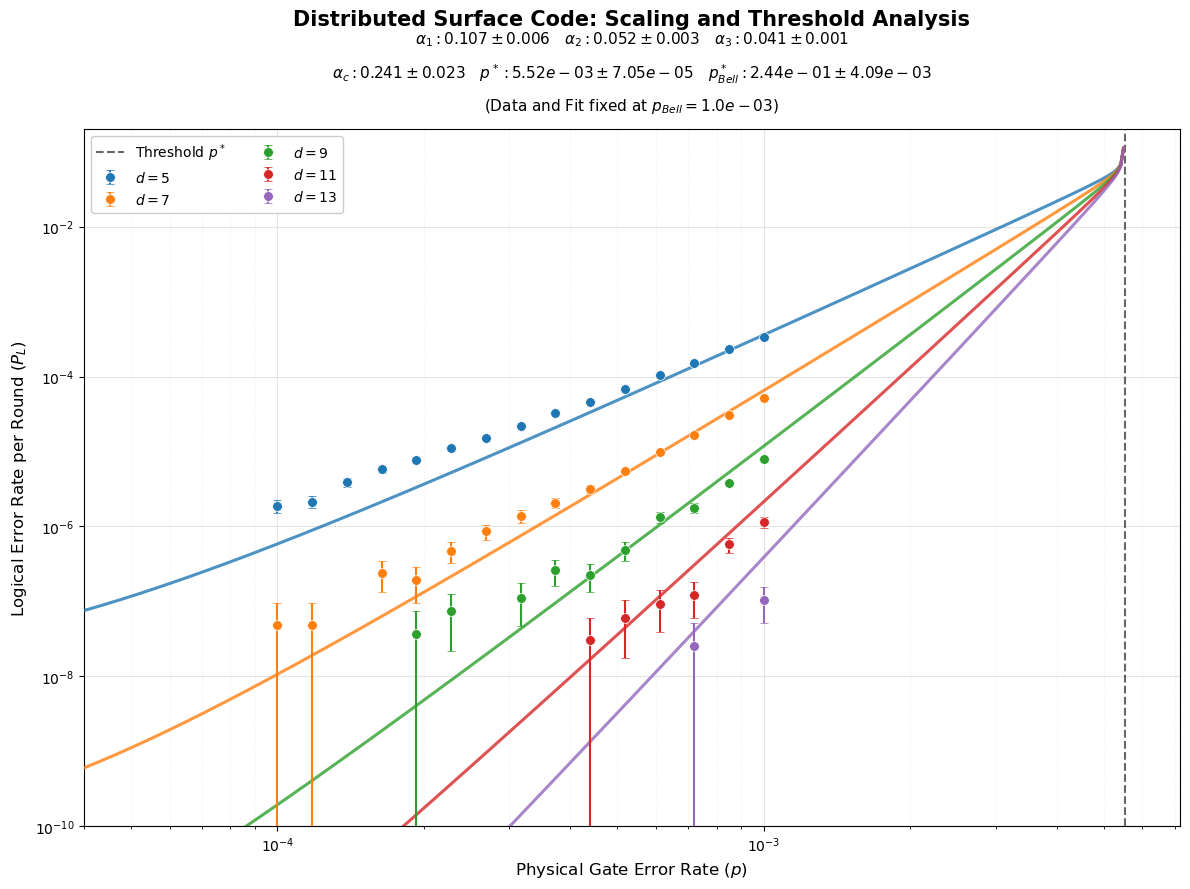

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------- 1. Pull Best-Fit Params ----------
res_params = distributed_surface_code_results.params

# Helper to format value +/- error for LaTeX
def fmt_val_err(name):
    p = res_params[name]
    val = p.value
    err = p.stderr if p.stderr is not None else 0
    
    # Use scientific notation for the probability thresholds
    if 'st' in name:
        return f"{val:.2e} \pm {err:.2e}"
    # Use standard notation for scaling coefficients
    return f"{val:.3f} \pm {err:.3f}"

# ---------- 2. Data Preparation ----------
x_arr = np.array(x, dtype=float)
p_pts = x_arr[:, 0]
d_pts = x_arr[:, 1].astype(int)
pbell_pts = x_arr[:, 2]
data_arr = np.array(data)

print(pbell_pts)
pL_pts = np.array([p_L(xi, dat) for xi, dat in zip(x_arr, data_arr)], dtype=float)

# Fix pBell to the very first value encountered
fixed_p_bell = pbell_pts[6]

# ---------- 3. Plotting ----------
plt.figure(figsize=(12, 9))
unique_distances = sorted(set(d_pts))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Set X-axis range based on the physical threshold p^*
p_star_val = res_params['p_st'].value
p_min_plot = p_pts.min() * 0.4
p_max_plot = p_star_val * 1.3
p_grid = np.logspace(np.log10(p_min_plot), np.log10(p_star_val * 1.1), 400)

for i, d in enumerate(unique_distances):
    mask = (d_pts == d) & (np.isclose(pbell_pts, fixed_p_bell, atol=1e-12))
    
    if not np.any(mask):
        continue
    
    y_errs = [std(xi, dat, shots) for xi, dat in zip(x_arr[mask], data_arr[mask])]
    plt.errorbar(p_pts[mask], pL_pts[mask], yerr=y_errs, fmt='o', 
                 label=f"$d={d}$", color=colors[i], capsize=3, 
                 markersize=7, markeredgecolor='white', markeredgewidth=0.5, zorder=4)

    y_fit = [ansatz([p, d, fixed_p_bell], 
                    res_params['alpha_1'].value, res_params['alpha_2'].value, 
                    res_params['alpha_3'].value, res_params['alpha_c'].value, 
                    res_params['p_st'].value, res_params['p_bell_st'].value) for p in p_grid]
    plt.plot(p_grid, y_fit, color=colors[i], linestyle='-', linewidth=2.2, alpha=0.8, zorder=3)

# --- Axis Styling ---
plt.xscale("log")
plt.yscale("log")
plt.xlim(p_min_plot, p_max_plot)
plt.ylim(1e-10, 0.2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Physical Threshold Line (p^*)
plt.axvline(p_star_val, color='black', linestyle="--", linewidth=1.5, alpha=0.6, 
            label=r"Threshold $p^*$", zorder=2)

# --- Title and Updated Subtitle Notation ---
plt.title("Distributed Surface Code: Scaling and Threshold Analysis", 
          fontsize=15, fontweight='bold', pad=75)

# Multi-line subtitle using superscript '*'
line1 = (fr"$\alpha_1: {fmt_val_err('alpha_1')} \quad "
         fr"\alpha_2: {fmt_val_err('alpha_2')} \quad "
         fr"\alpha_3: {fmt_val_err('alpha_3')}$")

line2 = (fr"$\alpha_c: {fmt_val_err('alpha_c')} \quad "
         fr"p^*: {fmt_val_err('p_st')} \quad "
         fr"p_{{Bell}}^*: {fmt_val_err('p_bell_st')}$")

line3 = fr"(Data and Fit fixed at $p_{{Bell}} = {fixed_p_bell:.1e}$)"

full_subtitle = f"{line1}\n{line2}\n{line3}"

plt.text(0.5, 1.02, full_subtitle, transform=ax.transAxes, ha='center', 
         fontsize=11, linespacing=1.8, va='bottom')

plt.xlabel("Physical Gate Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate per Round ($P_L$)", fontsize=12)

plt.grid(True, which="major", ls="-", color='0.8', alpha=0.5, zorder=1)
plt.grid(True, which="minor", ls=":", color='0.8', alpha=0.3, zorder=1)

plt.legend(loc='upper left', frameon=True, fontsize=10, ncol=2, facecolor='white', framealpha=1)

plt.tight_layout()
plt.show()

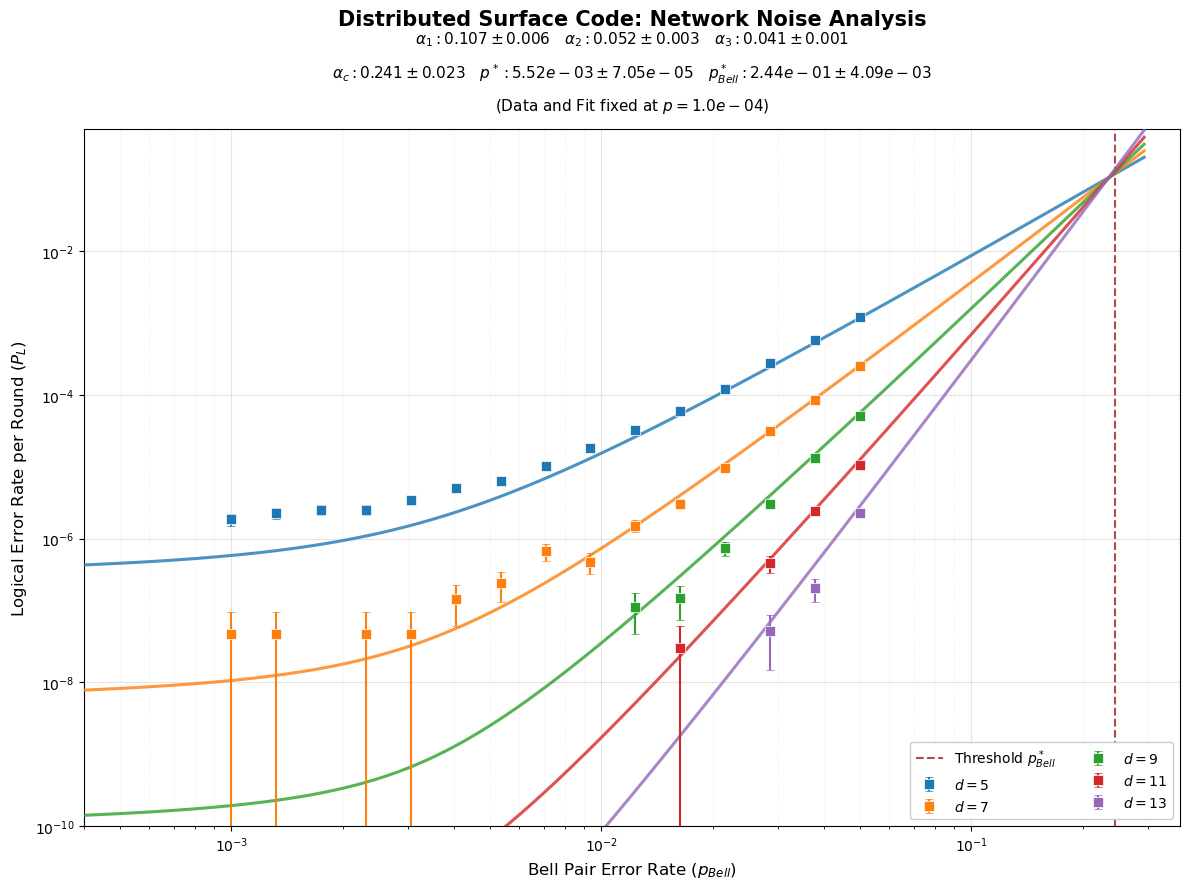

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------- 1. Pull Best-Fit Params ----------
res_params = distributed_surface_code_results.params

def fmt_val_err(name):
    p = res_params[name]
    val = p.value
    err = p.stderr if p.stderr is not None else 0
    if 'st' in name:
        return f"{val:.2e} \pm {err:.2e}"
    return f"{val:.3f} \pm {err:.3f}"

# ---------- 2. Data Preparation ----------
x_arr = np.array(x, dtype=float)  # [p, d, p_Bell]
p_pts = x_arr[:, 0]
d_pts = x_arr[:, 1].astype(int)
pbell_pts = x_arr[:, 2]
data_arr = np.array(data)

pL_pts = np.array([p_L(xi, dat) for xi, dat in zip(x_arr, data_arr)], dtype=float)

# FIX physical gate error p to the first value encountered
# To match the paper's logic, this is often 1e-3
fixed_p = p_pts[20] 

# ---------- 3. Plotting ----------
plt.figure(figsize=(12, 9))
unique_distances = sorted(set(d_pts))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Set X-axis range based on the Bell threshold p_Bell^*
p_bell_star_val = res_params['p_bell_st'].value
p_bell_min_plot = pbell_pts.min() * 0.4
p_bell_max_plot = p_bell_star_val * 1.5
p_bell_grid = np.logspace(np.log10(p_bell_min_plot), np.log10(p_bell_star_val * 1.2), 400)

for i, d in enumerate(unique_distances):
    # Mask for fixed p and current distance d
    mask = (d_pts == d) & (np.isclose(p_pts, fixed_p, atol=1e-12))
    
    if not np.any(mask):
        continue
    
    # Plot experimental data points against p_Bell
    y_errs = [std(xi, dat, shots) for xi, dat in zip(x_arr[mask], data_arr[mask])]
    plt.errorbar(pbell_pts[mask], pL_pts[mask], yerr=y_errs, fmt='s', # square markers for pBell
                 label=f"$d={d}$", color=colors[i], capsize=3, 
                 markersize=7, markeredgecolor='white', markeredgewidth=0.5, zorder=4)

    # Plot theoretical fit lines using fixed_p
    y_fit = [ansatz([fixed_p, d, pb], 
                    res_params['alpha_1'].value, res_params['alpha_2'].value, 
                    res_params['alpha_3'].value, res_params['alpha_c'].value, 
                    res_params['p_st'].value, res_params['p_bell_st'].value) for pb in p_bell_grid]
    plt.plot(p_bell_grid, y_fit, color=colors[i], linestyle='-', linewidth=2.2, alpha=0.8, zorder=3)

# --- Axis Styling ---
plt.xscale("log")
plt.yscale("log")
plt.xlim(p_bell_min_plot, p_bell_max_plot)
plt.ylim(1e-10, 0.5) # Bell noise often goes higher before failing

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Network Threshold Line (p_Bell^*)
plt.axvline(p_bell_star_val, color='darkred', linestyle="--", linewidth=1.5, alpha=0.7, 
            label=r"Threshold $p_{Bell}^*$", zorder=2)

# --- Title and Subtitle ---
plt.title("Distributed Surface Code: Network Noise Analysis", 
          fontsize=15, fontweight='bold', pad=75)

line1 = (fr"$\alpha_1: {fmt_val_err('alpha_1')} \quad "
         fr"\alpha_2: {fmt_val_err('alpha_2')} \quad "
         fr"\alpha_3: {fmt_val_err('alpha_3')}$")

line2 = (fr"$\alpha_c: {fmt_val_err('alpha_c')} \quad "
         fr"p^*: {fmt_val_err('p_st')} \quad "
         fr"p_{{Bell}}^*: {fmt_val_err('p_bell_st')}$")

line3 = fr"(Data and Fit fixed at $p = {fixed_p:.1e}$)"

full_subtitle = f"{line1}\n{line2}\n{line3}"

plt.text(0.5, 1.02, full_subtitle, transform=ax.transAxes, ha='center', 
         fontsize=11, linespacing=1.8, va='bottom')

plt.xlabel("Bell Pair Error Rate ($p_{Bell}$)", fontsize=12)
plt.ylabel("Logical Error Rate per Round ($P_L$)", fontsize=12)

plt.grid(True, which="major", ls="-", color='0.8', alpha=0.5, zorder=1)
plt.grid(True, which="minor", ls=":", color='0.8', alpha=0.3, zorder=1)

plt.legend(loc='lower right', frameon=True, fontsize=10, ncol=2, facecolor='white', framealpha=1)

plt.tight_layout()
plt.show()